In [ ]:
import tomobase 
import tomondt
import pathlib
import os 
import stackview

#Rod-D jumping-mountain-36 or olive-darkness-63
#Cage-D sage-forest-34
file_name = 'Cage-D'
instance_name = 'jumping-mountain-36'
ref_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\Volumes128', file_name+'.vmf'))
dip_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\DIP128', file_name+'_'+instance_name+'.vmf'))

print(dip_path)
ref = tomondt.read_vmf(ref_path)
dip = tomondt.read_vmf(dip_path)




\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\DIP128\Rod-D_jumping-mountain-36.vmf


In [ ]:

from tomobase.data import Sinogram, Volume
from tomobase.processes import project
import copy

sino_path = pathlib.Path(os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\TiltSeries128', file_name+'.mat'))
sino_ref = Sinogram.from_file(sino_path)
sino_dip = copy.deepcopy(sino_ref)

print(sino_ref.angles)
for i, t in enumerate(dip.times):
    sino_dip.data[i,:,:] = project(Volume(dip.read_record(t).transpose(2,1,0)), [sino_ref.angles[i]]).data

sino_ref = tomobase.processes.background_subtract_median(sino_ref)
sino_dip = tomobase.processes.background_subtract_median(sino_dip)

sino_dip = tomobase.processes.normalize(sino_dip)
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [ ]:
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [44]:
# convert_to_vmf
from tomobase.data import Volume
import pathlib
import os

from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

min =10000
max = -10000
for t in dip.times:

    vol_ref = ref.read_record(t)
    thresh = threshold_otsu(vol_ref)
    mask = np.zeros_like(vol_ref)
    mask[vol_ref>=thresh] = 1.0
    mask = binary_dilation(mask, iterations=4)

    vol = dip.read_record(t).transpose(0,2,1).copy()
    thresh = threshold_otsu(vol)
    vol = vol[~mask]

    if np.min(vol) < min:
        min = np.min(vol)
    if np.max(vol) > max:
        max = np.max(vol)


for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy() #.transpose(0,2,1)
    #vol_ref = ref.read_record(t)

def normalize_volume(vol, min, max):
    vol = (vol - min) / (max - min)
    return vol

def rmse(vol1, vol2):
    return np.sqrt(np.mean((vol1 - vol2) ** 2))*100

vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = normalize_volume(vol_ref, min, max)

print(max, min)
#stackview.side_by_side(vol_ref, vol_dip)

68.46647644042969 -6.073867321014404


In [43]:

vol_dip = dip.read_record(t).transpose(2,0,1).copy() #0,2,1
vol_ref = ref.read_record(t)
stackview.side_by_side(vol_dip, vol_ref)

side_by_side


In [ ]:
# convert_to_vmf
from tomobase.data import Volume
import pathlib
import os

from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

rec_path = pathlib.Path(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\Finalized_Samples\Volumes(AMIRA)\Cage-D_SIRT30_win30')

for i in range(1, 100):
    t = dip.times[i]
    vol = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))

    vol_dip = dip.read_record(t).transpose(2,0,1).copy()
    vol_ref = ref.read_record(t)

    thresh = threshold_otsu(vol_ref)
    mask = np.zeros_like(vol_ref)
    mask[vol_ref>=thresh] = 1.0
    mask = binary_dilation(mask, iterations=4)


    vol_dip = normalize_volume(vol_dip, min, max)
    vol_dip[~mask] = 0
    vol.data[~mask]= 0

    ssim_index = ssim(vol_ref, vol_dip, data_range= vol_ref.max() - vol_ref.min())
    ssim_rec = ssim(vol_ref, vol.data, data_range = vol_ref.max() - vol_ref.min() )
    rmse_value = rmse(vol_ref, vol_dip)
    rmse_rec = rmse(vol_ref, vol.data)
    
    print(f'{t}, {ssim_index}, {rmse_value}, {ssim_rec}, {rmse_rec},')
stackview.side_by_side(vol_ref, vol_dip)


2.0, 0.87414633459833, 13.17712624261219, 0.8751701106731615, 7.774612787936744,
3.0, 0.8753419743622777, 13.109096668988096, 0.8780501853589099, 7.606236922485575,
4.0, 0.8780485639052549, 13.359217532196505, 0.8805494734363463, 7.467937501262218,
5.0, 0.8771857080932841, 13.204881107095739, 0.8826870396301173, 7.3755108655139,
6.0, 0.8799224653062219, 13.349194148916066, 0.8849371199322232, 7.205911628062016,
7.0, 0.9082856011440987, 13.92783650720987, 0.9098686385408938, 5.415113713342374,
8.0, 0.9046465278358728, 14.076550764323963, 0.911292688959638, 5.395811205738112,
9.0, 0.9111003934062489, 13.945987432601697, 0.9124963646691348, 5.368873143355944,
10.0, 0.9103726038425649, 13.914934153408309, 0.9142219071550041, 5.327819405784533,
11.0, 0.9109545405067412, 13.974582177576048, 0.9155262658136226, 5.257983787830789,
12.0, 0.9127621041810784, 13.946489953737276, 0.9164792054043666, 5.270310769587868,
13.0, 0.9112702387087448, 13.926415140316992, 0.9170230689721914, 5.295673667233

In [ ]:
import shutil
import mrcz

folder = os.path.join(r'\\ematbyname\emat\TimC\DIPSTER-PublicationData\PData\DIP128\normalized2_mof_128_wendys-knows-all-28_rec')

if os.path.exists(folder):
    shutil.rmtree(folder)

os.mkdir(folder)
i = 0
for time in dip.times:
    vol = dip.read_record(time).transpose(1,0,2)
    vol = normalize_volume(vol, min, max)
    mrcz.writeMRC(vol, os.path.join(folder, str(i)+'data.rec'), pixelsize=[1/1280,1/1280,1/1280], pixelunits='nm')
    i+=1

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu

import numpy as np
from tomobase import processes
import stackview
import copy

threshold = threshold_otsu(vol_dip)

for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()
    vol_ref = ref.read_record(t)

    vol_dip2 = vol_dip.copy()
    vol_dip = np.zeros_like(vol_dip2)

    cv = 42
    vol_dip[cv:-cv, cv:-cv, cv:-cv] = vol_dip2[cv:-cv, cv:-cv, cv:-cv]
    

    vol_dip = normalize_volume(vol_dip, min, max)
    vol_dip[vol_dip < threshold] = 0

    ssim_index = ssim(vol_ref, vol_dip, data_range= vol_dip.max() - vol_dip.min())
    rmse_value = rmse(vol_ref, vol_dip)
    print(f'{t}, {ssim_index}, {rmse_value}')
stackview.side_by_side(vol_ref, vol_dip)

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.filters import threshold_otsu
from scipy.ndimage import binary_dilation
import numpy as np
from tomobase import processes
import stackview
import copy

threshold = threshold_otsu(sino_ref.data)
mask = np.zeros_like(sino_ref.data)
mask[sino_ref.data >= threshold] = 1

mask = binary_dilation(mask, iterations=4)

for i, t in enumerate(dip.times):
    cv = 42
    masked_sino_ref = copy.deepcopy(sino_ref)
    masked_sino_dip = copy.deepcopy(sino_dip)

    #masked_sino_dip.data= np.zeros_like(masked_sino_dip.data)
    #masked_sino_ref.data = np.zeros_like(masked_sino_ref.data)


    #masked_sino_dip[cv:-cv, cv:-cv, cv:-cv] = vol_dip2[cv:-cv, cv:-cv, cv:-cv]

    masked_sino_dip.data[~mask] = 0
    masked_sino_ref.data[~mask] = 0


    ssim_index = ssim(masked_sino_ref.data[i,:,:], masked_sino_dip.data[i,:,:], data_range= masked_sino_dip.data.max() - masked_sino_dip.data.min())
    rmse_value = rmse(masked_sino_ref.data[i,:,:], masked_sino_dip.data[i,:,:])
    print(f'{t}, {sino_ref.angles[i]}, {ssim_index}, {rmse_value}')
stackview.side_by_side(sino_ref.data, sino_dip.data)

In [49]:
import numpy as np
import scipy.ndimage as ndi

def surface_area_volume(vol, threshold=None):
    # Build a binary object mask
    if threshold is None:
        obj = vol.astype(bool)   # assumes already binary/nonzero = object
    else:
        obj = vol > threshold
        cv = 30
        obj2 = np.zeros_like(obj, dtype=bool)
        obj2[cv:-cv, cv:-cv, cv:-cv] = obj[cv:-cv, cv:-cv, cv:-cv]
        obj = obj2

    volume = int(obj.sum())
    if volume == 0:
        return 0.0, 0, 0, 0

    # 6-connectivity is common for voxel surface
    structure = ndi.generate_binary_structure(3, 1)  # 3D, 6-neighborhood
    eroded = ndi.binary_erosion(obj, structure=structure, border_value=0)

    surface = obj & (~eroded)
    sa = int(surface.sum())  # "surface voxels", not physical area

    return sa / volume, sa, volume, obj


vol_dip = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))
vol_dip = vol_dip.data
#vol_ref = ref.read_record(dip.times[0]).copy()
thr = threshold_otsu(vol_dip)
# thr_ref = threshold_otsu(vol_ref)
iters = 0
limit = 120
for i in range(100):
    vol_dip = Volume.from_file(os.path.join(rec_path, f'{i} data.rec'))
    vol_dip= vol_dip.data
    #vol_ref = ref.read_record(t).copy()

    #vol_dip = normalize_volume(vol_dip, min, max)

    # compute threshold per-volume *after* normalization, or use a fixed threshold in normalized units
    thr = threshold_otsu(vol_dip)
    sa_vol_dip, sa_dip, vol_dip_count, obj_dip = surface_area_volume(vol_dip, threshold=thr)

    # if vol_ref is not binary, decide thresholding strategy for ref too
    #sa_vol_ref, sa_ref, vol_ref_count, obj_ref = surface_area_volume(vol_ref, threshold=thr_ref)

    #error = abs(sa_vol_dip - sa_vol_ref)
    #error_percent = error / sa_vol_ref * 100 if sa_vol_ref != 0 else 0.0
    #print(t, sa_vol_ref, sa_vol_dip, error, error_percent, sa_ref, vol_ref_count)
    print(t, sa_vol_dip, sa_dip, vol_dip_count)
    if iters == limit:
        break 
    iters += 1
#stackview.side_by_side(obj_ref, obj_dip)


100.0 0.11991255961844197 12068 100640
100.0 0.11836055176787696 11944 100912
100.0 0.11613975419339878 12020 103496
100.0 0.1170611670963206 11988 102408
100.0 0.11882510013351134 12104 101864
100.0 0.11648300481142325 12008 103088
100.0 0.11672674284837795 12176 104312
100.0 0.11729967577582213 12156 103632
100.0 0.11684073107049608 12172 104176
100.0 0.11299712687131408 11956 105808
100.0 0.11490399268515697 12064 104992
100.0 0.11402714932126697 12096 106080
100.0 0.11325197630305182 12120 107018
100.0 0.11316810988354732 12128 107168
100.0 0.1130619548199508 12132 107304
100.0 0.1129560685033507 12136 107440
100.0 0.11222230422909439 12164 108392
100.0 0.11109493302271403 12208 109888
100.0 0.11129762078528682 12200 109616
100.0 0.11099396495310114 12212 110024
100.0 0.11069255288322226 12224 110432
100.0 0.11009636128289947 12248 111248
100.0 0.1088341473773625 12300 113016
100.0 0.10766617116160544 12168 113016
100.0 0.10838478180570946 12324 113706
100.0 0.10864345738295318 123

In [ ]:
import numpy as np
import scipy.ndimage as ndi
import copy

def alloying(vol, initial, final):
    volume = copy.deepcopy(vol) 

    threshold = 0.35
    mask = volume >= threshold
    value = np.std(volume[mask])
    count = np.count_nonzero(mask)
    #print(np.max(volume[mask]), np.min(volume[mask]))
    if np.max(volume[mask]) > 0.988:
        #print('Max exceeded')
        pass
    alloying = (value-initial)/(final- initial)
    #print('Exp', initial, final, value)
    return alloying*100, count, volume

vol_dip = dip.read_record(dip.times[0]).transpose(0,2,1).copy()
vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = ref.read_record(ref.times[0]).copy()
thr = threshold_otsu(vol_dip)
thr_ref = 0.1

iters = 0
limit = 100

m1 = 0.3
m2 = 1.0

mask = vol_ref >= thr_ref
vol_ref[vol_ref <= thr_ref] = 0

c2 = np.count_nonzero(vol_ref>= m2)
c1 = np.count_nonzero((vol_ref < m2) & (vol_ref >= m1))
initial = np.std(vol_ref[mask])

total=c1+c2
hetorogenous = m1*(c1/total) + m2*(1 - c1/total)
final_vol = copy.deepcopy(vol_ref)
final_vol[mask] = hetorogenous
final = np.std(final_vol[mask])

#print(f'c1: {c1}, c2: {c2}, sum: {c1 + c2}, initial: {initial} final: {final}')
for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()
    vol_ref = ref.read_record(t).copy()

    vol_dip = normalize_volume(vol_dip, min, max)
    alloying_dip, count_dip, obj_dip = alloying(vol_dip, initial, final)
    alloying_ref, count_ref,obj_ref = alloying(vol_ref, initial, final)

    error = abs(alloying_dip - alloying_ref)
    error_percent = error / alloying_ref * 100 if alloying_ref != 0 else 0.0
    print(t, alloying_ref, alloying_dip, error, error_percent, count_dip, count_ref)
    if iters == limit:
        break 
    iters += 1
stackview.side_by_side(obj_ref, obj_dip)



[-0.45488917  0.3457357 ]


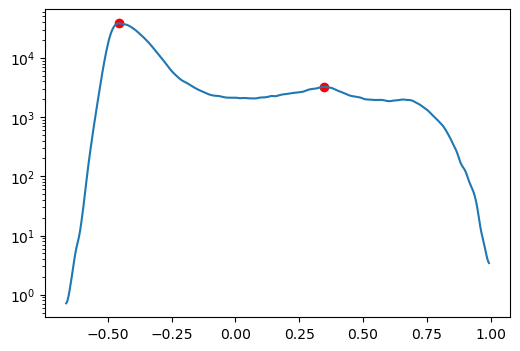

In [52]:
import numpy as np
import matplotlib.pyplot as plt

data = normalize_volume(dip.read_record(dip.times[0]).copy(), min, max)
vals = data
hist, edges = np.histogram(vals, bins=400)
centers = 0.5 * (edges[:-1] + edges[1:])

from scipy.ndimage import gaussian_filter1d
hist_smooth = gaussian_filter1d(hist.astype(float), sigma=2)

from scipy.signal import find_peaks

peaks, props = find_peaks(hist_smooth, prominence=0.01 * hist_smooth.max())
print(centers[peaks])
plt.figure(figsize=(6,4))
plt.plot(centers, hist_smooth)
plt.scatter(centers[peaks], hist_smooth[peaks], color="red")
plt.yscale("log")
plt.show()
stackview.orthogonal(data)

In [56]:
import numpy as np
import scipy.ndimage as ndi
import copy

def alloying(vol, initial, final):
    volume = copy.deepcopy(vol) 

    threshold = 0.17
    mask = volume >= threshold
    value = np.std(volume[mask])
    count = np.count_nonzero(mask)
    #print(np.max(volume[mask]), np.min(volume[mask]))
    if np.max(volume[mask]) > 0.988:
        #print('Max exceeded')
        pass
    alloying = (value-initial)/(final- initial)
    #print('Exp', initial, final, value)
    return alloying*100, count, volume

vol_dip = dip.read_record(dip.times[0]).transpose(0,2,1).copy()
vol_dip = normalize_volume(vol_dip, min, max)
#vol_ref = ref.read_record(ref.times[0]).copy()
thr = threshold_otsu(vol_dip)
thr_ref = 0.17

iters = 0
limit = 100

m1 = 0.35
m2 = 0.75

mask = vol_dip >= thr_ref
#vol_ref[vol_ref <= thr_ref] = 0

c2 = np.count_nonzero(vol_dip>= (m2+m1)/2)
c1 = np.count_nonzero((vol_dip < (m2+m1)/2) & (vol_dip >= (m1/2)))
initial = np.std(vol_dip[mask])

total=c1+c2
hetorogenous = m1*(c1/total) + m2*(1 - c1/total)
final_vol = copy.deepcopy(vol_dip)
final_vol[mask] = hetorogenous
final = np.std(final_vol[mask])

#print(f'c1: {c1}, c2: {c2}, sum: {c1 + c2}, initial: {initial} final: {final}')
for t in dip.times:
    vol_dip = dip.read_record(t).transpose(0,2,1).copy()
    #vol_ref = ref.read_record(t).copy()

    vol_dip = normalize_volume(vol_dip, min, max)
    alloying_dip, count_dip, obj_dip = alloying(vol_dip, initial, final)
    #alloying_ref, count_ref,obj_ref = alloying(vol_ref, initial, final)

    #error = abs(alloying_dip - alloying_ref)
    #error_percent = error / alloying_ref * 100 if alloying_ref != 0 else 0.0
    #print(t, alloying_ref, alloying_dip, error, error_percent, count_dip, count_ref)
    print(t, alloying_dip, count_dip)
    if iters == limit:
        break 
    iters += 1
#stackview.side_by_side( obj_dip)

3.439913034439087 -0.0 348696
64.43603515625 -0.055338417778244185 350684
139.21839904785156 -0.053193348432885 353066
205.09690856933594 -0.005397063434516524 355283
273.8526916503906 0.1284509907903153 357719
366.05743408203125 0.4894822486613105 361115
461.1935729980469 1.0295311181860973 364962
536.474609375 1.6228738991770335 368362
641.4407958984375 2.778903214390447 373275
728.00390625 3.9004012847245457 377616
812.2478637695312 5.185941908213631 381794
877.523193359375 6.231457837954788 385011
968.6986083984375 7.820687797531079 389610
1070.169677734375 9.731062945824158 394729
1181.1142578125 11.925368260268636 399882
1267.314208984375 13.71736859399392 403491
1323.6639404296875 14.875330162490407 405538
1405.3590087890625 16.49514442421211 407993
1491.6927490234375 18.149685296278616 409766
1571.6904296875 19.643817429794694 410694
1628.899658203125 20.68455425422423 411087
1688.7484130859375 21.73094695068567 411385
1775.728515625 23.1126298356684 411553
1841.5439453125 24.0